# Model Evaluation

This notebook performs comprehensive evaluation of the trained model.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, matthews_corrcoef
)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [2]:
# Load test data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Load the trained model
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

print(f"Model type: {type(model).__name__}")
print(f"Test set size: {X_test.shape}")

Model type: RandomForestClassifier
Test set size: (1405, 6559)


## Model Predictions

In [3]:
# Make predictions
y_pred = model.predict(X_test)

# Get prediction probabilities (if available)
if hasattr(model, 'predict_proba'):
    y_pred_proba = model.predict_proba(X_test)
    print("Prediction probabilities available")
else:
    y_pred_proba = None
    print("Prediction probabilities not available for this model")

Prediction probabilities available


## Classification Metrics

In [4]:
# Calculate all 6 required metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# Calculate AUC if probabilities are available
if y_pred_proba is not None:
    if y_pred_proba.shape[1] == 2:
        auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
else:
    auc = None

print("="*60)
print("Model Performance Metrics - All Required Metrics")
print("="*60)
print(f"1. Accuracy:  {accuracy:.4f}")
if auc is not None:
    print(f"2. AUC Score: {auc:.4f}")
else:
    print(f"2. AUC Score: N/A (probabilities not available)")
print(f"3. Precision: {precision:.4f}")
print(f"4. Recall:    {recall:.4f}")
print(f"5. F1-Score:  {f1:.4f}")
print(f"6. MCC Score: {mcc:.4f}")
print("="*60)

Model Performance Metrics - All Required Metrics
1. Accuracy:  0.7893
2. AUC Score: 0.8345
3. Precision: 0.7757
4. Recall:    0.7893
5. F1-Score:  0.7770
6. MCC Score: 0.4141


In [5]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.46      0.54       372

    accuracy                           0.79      1405
   macro avg       0.73      0.68      0.70      1405
weighted avg       0.78      0.79      0.78      1405



## Confusion Matrix

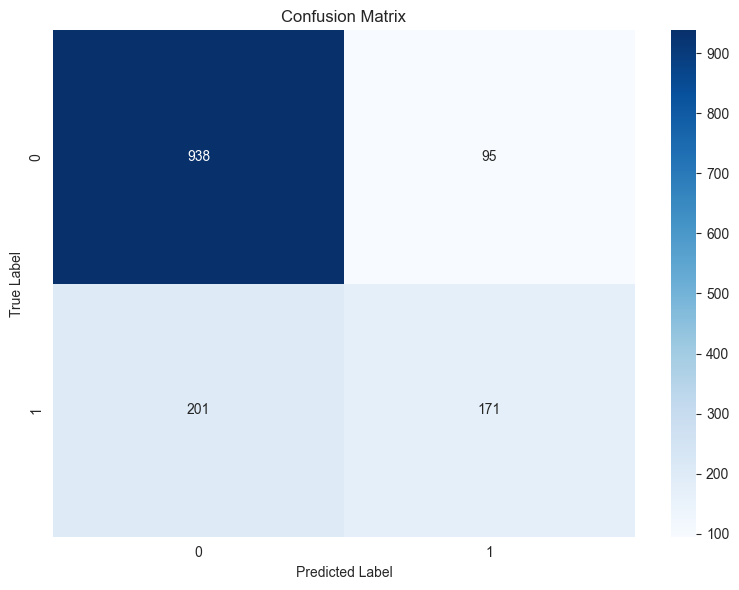

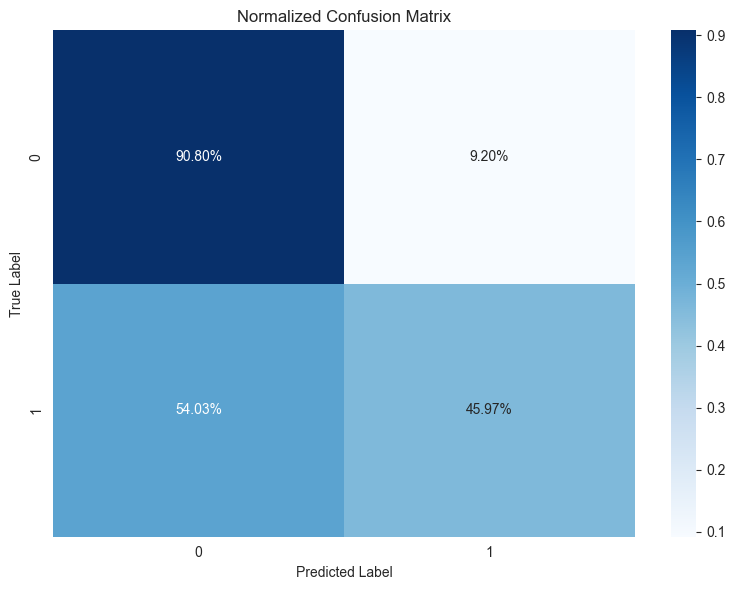

In [6]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Calculate and display confusion matrix percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=True)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## ROC Curve and AUC

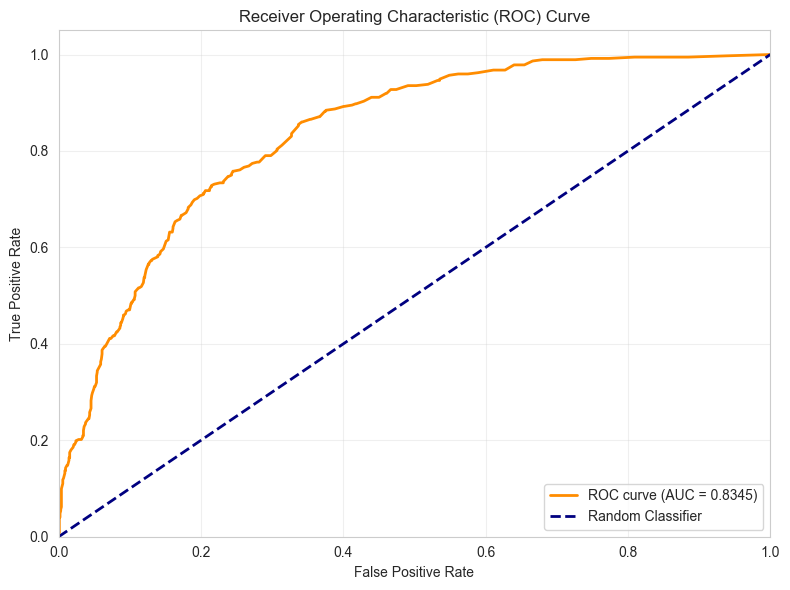


AUC-ROC Score: 0.8345


In [7]:
# ROC curve (for binary classification)
if y_pred_proba is not None and len(np.unique(y_test)) == 2:
    # Get probabilities for the positive class
    y_pred_proba_pos = y_pred_proba[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_pos)
    roc_auc = roc_auc_score(y_test, y_pred_proba_pos)
    
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nAUC-ROC Score: {roc_auc:.4f}")

## Precision-Recall Curve

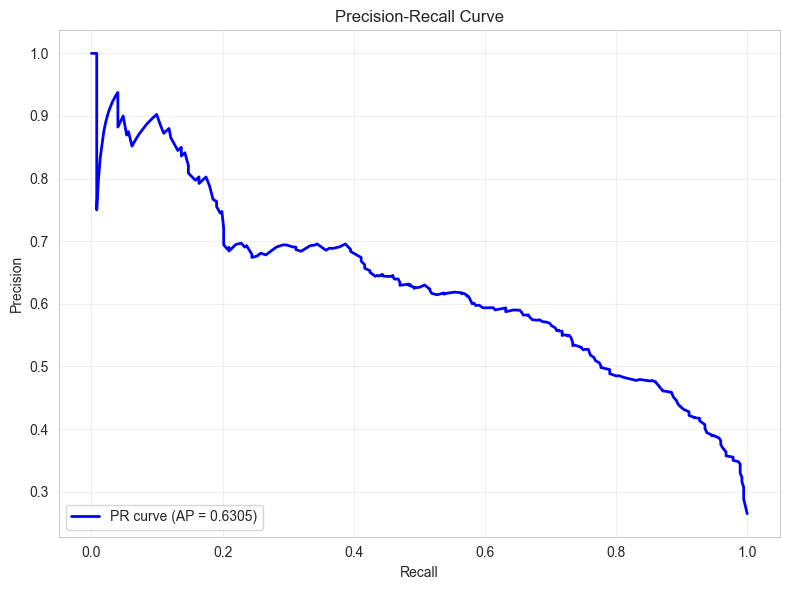


Average Precision Score: 0.6305


In [8]:
# Precision-Recall curve (for binary classification)
if y_pred_proba is not None and len(np.unique(y_test)) == 2:
    # Calculate Precision-Recall curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_pos)
    avg_precision = average_precision_score(y_test, y_pred_proba_pos)
    
    # Plot Precision-Recall curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals, precision_vals, color='blue', lw=2, 
             label=f'PR curve (AP = {avg_precision:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nAverage Precision Score: {avg_precision:.4f}")

## Error Analysis

In [9]:
# Analyze misclassified samples
misclassified_idx = np.where(y_test != y_pred)[0]
correctly_classified_idx = np.where(y_test == y_pred)[0]

print(f"Total misclassified samples: {len(misclassified_idx)}")
print(f"Total correctly classified samples: {len(correctly_classified_idx)}")
print(f"Error rate: {len(misclassified_idx) / len(y_test):.2%}")

# Show some misclassified examples
if len(misclassified_idx) > 0:
    print("\nSample of misclassified predictions:")
    misclassified_df = pd.DataFrame({
        'True Label': y_test[misclassified_idx[:10]],
        'Predicted Label': y_pred[misclassified_idx[:10]]
    })
    if y_pred_proba is not None:
        misclassified_df['Confidence'] = y_pred_proba[misclassified_idx[:10]].max(axis=1)
    print(misclassified_df)

Total misclassified samples: 296
Total correctly classified samples: 1109
Error rate: 21.07%

Sample of misclassified predictions:
   True Label  Predicted Label  Confidence
0           0                1    0.705000
1           1                0    0.555000
2           1                0    0.675000
3           0                1    0.590000
4           1                0    0.625000
5           1                0    0.515000
6           1                0    0.935000
7           1                0    0.575667
8           1                0    0.600000
9           1                0    0.655000


## Prediction Distribution

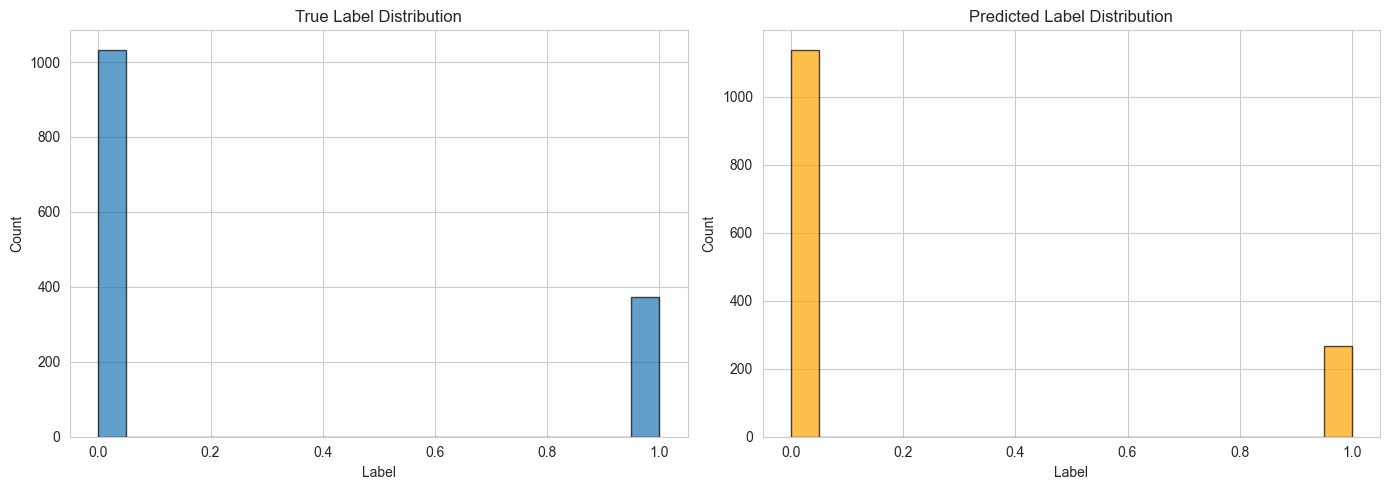

In [10]:
# Plot prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True labels distribution
axes[0].hist(y_test, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('True Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

# Predicted labels distribution
axes[1].hist(y_pred, bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Predicted Label Distribution')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Model Performance Summary

In [11]:
# Create a comprehensive summary
summary = {
    'Model Type': type(model).__name__,
    'Test Set Size': len(y_test),
    '1. Accuracy': f"{accuracy:.4f}",
    '3. Precision': f"{precision:.4f}",
    '4. Recall': f"{recall:.4f}",
    '5. F1-Score': f"{f1:.4f}",
    '6. MCC Score': f"{mcc:.4f}",
    'Misclassified': len(misclassified_idx),
    'Error Rate': f"{len(misclassified_idx) / len(y_test):.2%}"
}

if auc is not None:
    summary['2. AUC Score'] = f"{auc:.4f}"
if y_pred_proba is not None and len(np.unique(y_test)) == 2:
    summary['Average Precision'] = f"{avg_precision:.4f}"

print("\n" + "="*70)
print("MODEL EVALUATION SUMMARY - ALL REQUIRED METRICS")
print("="*70)
for key, value in summary.items():
    print(f"{key:.<35} {value}")
print("="*70)


MODEL EVALUATION SUMMARY - ALL REQUIRED METRICS
Model Type......................... RandomForestClassifier
Test Set Size...................... 1405
1. Accuracy........................ 0.7893
3. Precision....................... 0.7757
4. Recall.......................... 0.7893
5. F1-Score........................ 0.7770
6. MCC Score....................... 0.4141
Misclassified...................... 296
Error Rate......................... 21.07%
2. AUC Score....................... 0.8345
Average Precision.................. 0.6305


## Save Evaluation Results

In [12]:
# Save predictions for further analysis
results_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred
})

if y_pred_proba is not None:
    for i in range(y_pred_proba.shape[1]):
        results_df[f'Prob_Class_{i}'] = y_pred_proba[:, i]

results_df.to_csv('../data/processed/predictions.csv', index=False)
print("\nPredictions saved to '../data/processed/predictions.csv'")


Predictions saved to '../data/processed/predictions.csv'
